# Week 3 — Classification Models: Titanic

## Objective
Use the Kaggle Titanic dataset to build and compare multiple supervised classification models.

### Models
- Logistic Regression
- K-Nearest Neighbors (KNN)
- Decision Tree
- Random Forest
- Support Vector Machine (SVM)
- Gaussian Naive Bayes
- Gradient Boosting

### Evaluation
Accuracy, Precision, Recall, F1-score, ROC-AUC, and Confusion Matrix.

## 1. Import Libraries

If using Google Colab, download `train.csv` from Kaggle first.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [3]:
from google.colab import files

uploaded = files.upload()

Saving train.csv to train.csv


## 2. Load the Kaggle Dataset

Kaggle source:
https://www.kaggle.com/competitions/titanic/data

Download `train.csv` and place it beside this notebook.

In [4]:
df = pd.read_csv("train.csv")

print("Shape:", df.shape)
df.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 3. Understand the Dataset

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
display(df.describe(include="all").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Dooley, Mr. Patrick",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,714.0,NaN,NaN,NaN,29.699118,14.526497,0.42,20.125,28.0,38.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [7]:
print("Missing values:")
display(df.isnull().sum().sort_values(ascending=False))

print("\nTarget distribution:")
display(df["Survived"].value_counts())

Missing values:


,0
Cabin,687
Age,177
Embarked,2
PassengerId,0
Name,0
Pclass,0
Survived,0
Sex,0
Parch,0
SibSp,0



Target distribution:


,count
Survived,
0,549
1,342


## 4. Exploratory Data Analysis

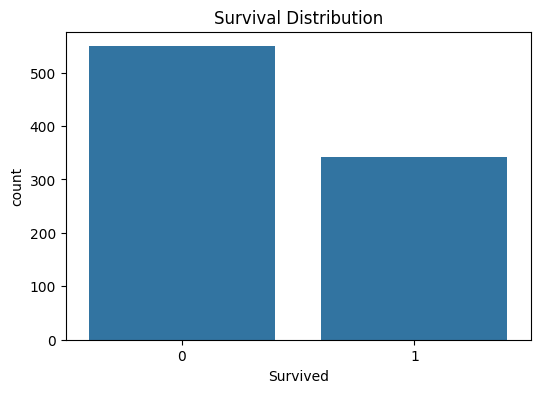

In [8]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Survived")
plt.title("Survival Distribution")
plt.show()

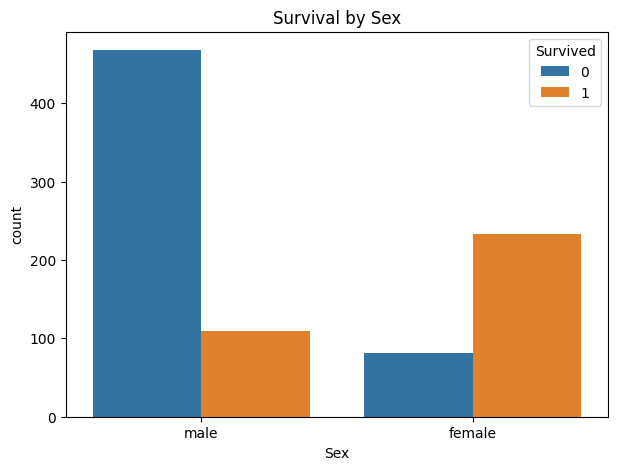

In [9]:
plt.figure(figsize=(7, 5))
sns.countplot(data=df, x="Sex", hue="Survived")
plt.title("Survival by Sex")
plt.show()

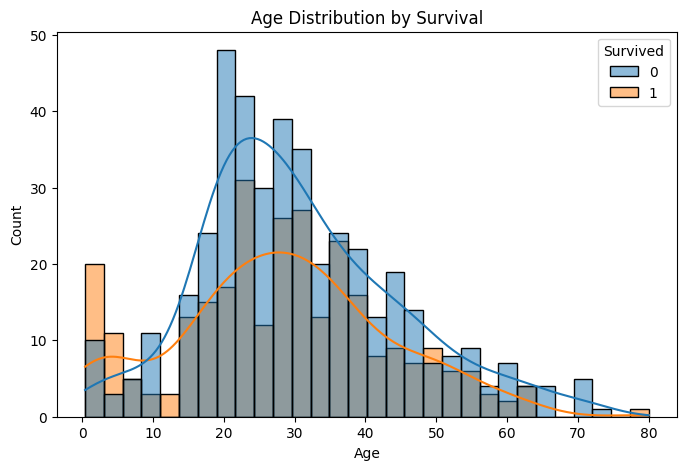

In [10]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="Age", hue="Survived", kde=True, bins=30)
plt.title("Age Distribution by Survival")
plt.show()

## 5. Feature Engineering

We:
- Extract `Title` from `Name`.
- Create `FamilySize`.
- Create `IsAlone`.
- Drop identifiers/text fields that are not directly useful.

In [11]:
data = df.copy()

data["Title"] = data["Name"].str.extract(r",\s*([^.]*)\.", expand=False).str.strip()

title_map = {"Mlle": "Miss", "Ms": "Miss", "Mme": "Mrs"}
data["Title"] = data["Title"].replace(title_map)

common_titles = ["Mr", "Miss", "Mrs", "Master"]
data.loc[~data["Title"].isin(common_titles), "Title"] = "Rare"

data["FamilySize"] = data["SibSp"] + data["Parch"] + 1
data["IsAlone"] = (data["FamilySize"] == 1).astype(int)

data = data.drop(columns=["Name", "Ticket", "Cabin", "PassengerId"], errors="ignore")

display(data.head())

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Title,FamilySize,IsAlone
0,0,3,male,22.0,1,0,7.2500,S,Mr,2,0
1,1,1,female,38.0,1,0,71.2833,C,Mrs,2,0
2,1,3,female,26.0,0,0,7.9250,S,Miss,1,1
3,1,1,female,35.0,1,0,53.1000,S,Mrs,2,0
4,0,3,male,35.0,0,0,8.0500,S,Mr,1,1


## 6. Define Features (X) and Target (y)

In [12]:
X = data.drop(columns="Survived")
y = data["Survived"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (891, 10)
y shape: (891,)


## 7. Train/Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 712
Testing rows: 179


## 8. Preprocessing

Numerical columns are median-imputed and scaled.
Categorical columns are imputed and one-hot encoded.

In [14]:
numeric_features = ["Age", "Fare", "SibSp", "Parch", "FamilySize", "IsAlone"]
categorical_features = ["Pclass", "Sex", "Embarked", "Title"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

## 9. Define Classification Models

In [15]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, max_depth=8, random_state=42, n_jobs=-1
    ),
    "SVM": SVC(probability=True, random_state=42),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

## 10. Train and Compare Models

In [16]:
results = []
trained_models = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_prob = pipeline.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })
    trained_models[name] = pipeline

results_df = pd.DataFrame(results).sort_values("F1", ascending=False)
results_df.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.8547,0.8413,0.7681,0.8030,0.8787
4,SVM,0.8436,0.8254,0.7536,0.7879,0.8451
5,Naive Bayes,0.8212,0.7606,0.7826,0.7714,0.8582
3,Random Forest,0.8268,0.8393,0.6812,0.7520,0.8502
6,Gradient Boosting,0.8156,0.8103,0.6812,0.7402,0.8505
1,KNN,0.7877,0.7541,0.6667,0.7077,0.8542
2,Decision Tree,0.7933,0.8200,0.5942,0.6891,0.8255


## 11. Visualize Model Comparison

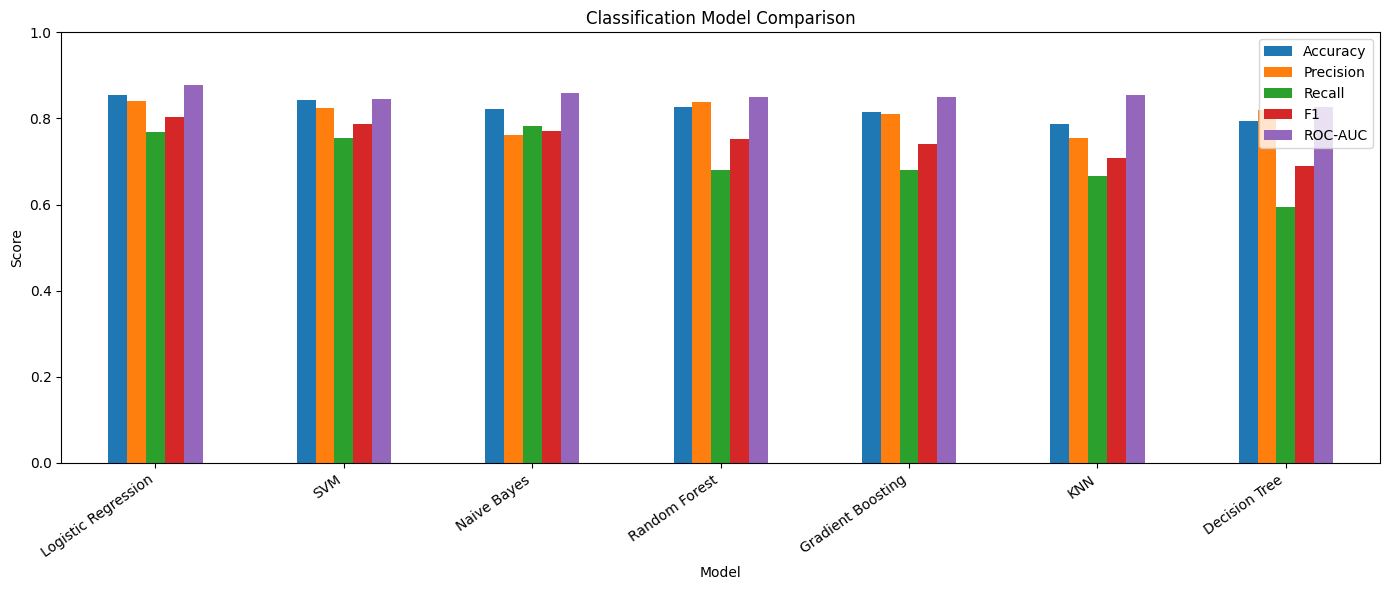

In [17]:
plot_df = results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]]
plot_df.plot(kind="bar", figsize=(14, 6))
plt.title("Classification Model Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

## 12. Detailed Evaluation of the Best Model

In [18]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
best_pred = best_model.predict(X_test)

print("Best model:", best_model_name)
print()
print(classification_report(y_test, best_pred))

Best model: Logistic Regression

              precision    recall  f1-score   support

           0       0.86      0.91      0.88       110
           1       0.84      0.77      0.80        69

    accuracy                           0.85       179
   macro avg       0.85      0.84      0.84       179
weighted avg       0.85      0.85      0.85       179



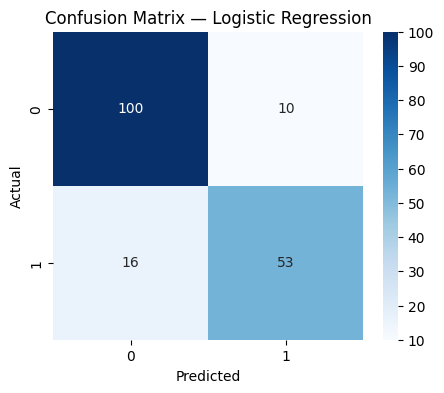

In [19]:
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix — {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 13. Cross-Validation

In [20]:
cv_results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring="f1")

    cv_results.append({
        "Model": name,
        "CV F1 Mean": scores.mean(),
        "CV F1 Std": scores.std()
    })

cv_df = pd.DataFrame(cv_results).sort_values("CV F1 Mean", ascending=False)
cv_df.round(4)

,Model,CV F1 Mean,CV F1 Std
0,Logistic Regression,0.7567,0.0315
4,SVM,0.7538,0.0236
5,Naive Bayes,0.7451,0.0422
6,Gradient Boosting,0.7420,0.0464
3,Random Forest,0.7397,0.0438
1,KNN,0.7358,0.0442
2,Decision Tree,0.7137,0.0605


## 14. Short Comparison and Conclusion

- **Logistic Regression:** strong baseline and easy to interpret.
- **KNN:** predicts from nearby examples and needs scaling.
- **Decision Tree:** captures nonlinear rules but can overfit.
- **Random Forest:** combines many trees and improves robustness.
- **SVM:** powerful for complex boundaries but usually needs scaling.
- **Naive Bayes:** fast probabilistic baseline.
- **Gradient Boosting:** sequentially improves weak learners and is often strong on tabular data.

Select the final model using the metric that matches the problem. Compare validation/test performance, interpretability, speed, and overfitting.